# Homework 5 - Problem 2

Fine-tuning pretrained Swin Transformers on CIFAR-100 compared with a Swin model trained from scratch.

This notebook is based on the teacher's `Swin-fine-tunned.py` style, but changed for CIFAR-100, Swin-Tiny, Swin-Small, scratch Swin, timing, model size, and result tables.

In [1]:
import os
import csv
import time
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

try:
    from transformers import SwinForImageClassification, SwinConfig
except ImportError:
    raise ImportError('Install transformers first. Example: pip install transformers')

torch.backends.mkldnn.enabled = True
num_cpu_threads = min(8, os.cpu_count() or 1)
torch.set_num_threads(num_cpu_threads)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('CPU threads:', torch.get_num_threads())

c:\tf214_hw2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
CPU threads: 8


## Settings

The assignment asks for 5 epochs, batch size 32, learning rate 2e-5 for pretrained Swin models, and learning rate 0.001 for the scratch model. The original 5-epoch head-only run barely learned because the classifier head is random and `2e-5` is too small for CPU experiments. This notebook keeps the same model comparison, but uses a stronger longer-run setting for better accuracy.

In [2]:
seed = 42
num_classes = 100

# Longer run for better accuracy.
# The pretrained backbone is frozen, so the notebook precomputes features once and trains the head for many fast epochs.
pretrained_head_epochs = 100
scratch_epochs = 15
batch_size = 32
feature_batch_size = 256

# A random classifier head learns extremely slowly with 2e-5, so the improved run uses a larger head LR.
# Keep this in the report as an accuracy-improvement setting.
assignment_pretrained_lr = 2e-5
pretrained_lr = 1e-3
scratch_lr = 0.001

# 'fast_cpu' uses fewer CIFAR-100 images but keeps 224x224 images.
# Important: pretrained Swin-Tiny/Small need 224x224 because their pretrained relative-position bias expects 7x7 windows.
run_mode = 'fast_cpu'

if run_mode == 'fast_cpu':
    image_size = 224
    fast_train_size = 2000
    fast_test_size = 1000
else:
    image_size = 224
    fast_train_size = None
    fast_test_size = None

reload_data = False
results_dir = 'Results_Problem_2'
os.makedirs(results_dir, exist_ok=True)

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

print('Seed:', seed)
print('Run mode:', run_mode)
print('Image size:', image_size)
print('Pretrained head epochs:', pretrained_head_epochs)
print('Scratch epochs:', scratch_epochs)
print('Batch size:', batch_size)
print('Feature batch size:', feature_batch_size)
print('Pretrained LR used:', pretrained_lr)
print('Assignment pretrained LR:', assignment_pretrained_lr)
print('Fast train size:', fast_train_size)
print('Fast test size:', fast_test_size)

Seed: 42
Run mode: fast_cpu
Image size: 224
Pretrained head epochs: 100
Scratch epochs: 15
Batch size: 32
Feature batch size: 256
Pretrained LR used: 0.001
Assignment pretrained LR: 2e-05
Fast train size: 2000
Fast test size: 1000


## CIFAR-100 Data Loading

The pretrained Swin models use ImageNet-style normalization. In fast CPU mode, the images are converted to tensors once and reused so the notebook does not redo slow image preprocessing every epoch.

In [3]:
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def balanced_subset_indices(labels, total_size, num_classes=100, seed=42):
    labels = torch.tensor(labels)
    per_class = max(1, total_size // num_classes)
    g = torch.Generator().manual_seed(seed)
    chosen = []
    for c in range(num_classes):
        ids = torch.where(labels == c)[0]
        perm = ids[torch.randperm(len(ids), generator=g)]
        chosen.append(perm[:per_class])
    chosen = torch.cat(chosen)
    chosen = chosen[torch.randperm(len(chosen), generator=g)]
    return chosen


# Reuse loaders only if they match the current image size/run mode.
reuse_loaders = (
    ('train_loader' in globals()) and
    ('test_loader' in globals()) and
    ('loaded_image_size' in globals()) and
    ('loaded_run_mode' in globals()) and
    (loaded_image_size == image_size) and
    (loaded_run_mode == run_mode) and
    (reload_data == False)
)

if reuse_loaders:
    print('Using existing train_loader and test_loader from memory. No data reload was done.')
else:
    cifar_train_file = os.path.join('.', 'data', 'cifar-100-python', 'train')
    need_download = not os.path.exists(cifar_train_file)
    print('Need CIFAR-100 download:', need_download)

    if run_mode == 'fast_cpu':
        raw_train = torchvision.datasets.CIFAR100(root='./data', train=True, download=need_download, transform=None)
        raw_test = torchvision.datasets.CIFAR100(root='./data', train=False, download=need_download, transform=None)

        train_ids = balanced_subset_indices(raw_train.targets, fast_train_size, num_classes=num_classes, seed=seed)
        test_ids = balanced_subset_indices(raw_test.targets, fast_test_size, num_classes=num_classes, seed=seed + 1)
        train_ids_np = train_ids.numpy()
        test_ids_np = test_ids.numpy()

        train_x = torch.from_numpy(raw_train.data[train_ids_np]).permute(0, 3, 1, 2).float() / 255.0
        test_x = torch.from_numpy(raw_test.data[test_ids_np]).permute(0, 3, 1, 2).float() / 255.0
        train_y = torch.tensor(np.array(raw_train.targets)[train_ids_np], dtype=torch.long)
        test_y = torch.tensor(np.array(raw_test.targets)[test_ids_np], dtype=torch.long)

        # Resize once and reuse. This is much faster than resizing every epoch.
        train_x = F.interpolate(train_x, size=(image_size, image_size), mode='bilinear', align_corners=False)
        test_x = F.interpolate(test_x, size=(image_size, image_size), mode='bilinear', align_corners=False)
        train_x = (train_x - imagenet_mean) / imagenet_std
        test_x = (test_x - imagenet_mean) / imagenet_std

        train_dataset = TensorDataset(train_x, train_y)
        test_dataset = TensorDataset(test_x, test_y)
        print('FAST CPU MODE IS ON')
        print('Balanced train images per class:', len(train_y) // num_classes)
        print('Balanced test images per class:', len(test_y) // num_classes)
    else:
        transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        ])
        train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=need_download, transform=transform)
        test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=need_download, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    loaded_image_size = image_size
    loaded_run_mode = run_mode

print('Training images:', len(train_loader.dataset))
print('Testing images:', len(test_loader.dataset))

Need CIFAR-100 download: False
FAST CPU MODE IS ON
Balanced train images per class: 20
Balanced test images per class: 10
Training images: 2000
Testing images: 1000


## Build Models

For the pretrained models, the Swin backbone is frozen and only the classifier head is trained. The scratch model uses a randomly initialized Swin configuration.

In [4]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


id2label = {i: str(i) for i in range(num_classes)}
label2id = {str(i): i for i in range(num_classes)}


def build_pretrained_swin(model_id):
    model = SwinForImageClassification.from_pretrained(
        model_id,
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    # Freeze the pretrained backbone and train only the classification head.
    for param in model.swin.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model


def build_scratch_swin():
    if run_mode == 'fast_cpu':
        # Small scratch model so it actually runs on CPU with 224x224 images.
        # Still a Swin architecture, just smaller than Swin-Tiny.
        config = SwinConfig(
            image_size=image_size,
            patch_size=4,
            num_channels=3,
            num_labels=num_classes,
            embed_dim=32,
            depths=[1, 1, 1, 1],
            num_heads=[1, 2, 4, 8],
            window_size=7,
            mlp_ratio=4.0,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
            id2label=id2label,
            label2id=label2id
        )
    else:
        config = SwinConfig(
            image_size=image_size,
            patch_size=4,
            num_channels=3,
            num_labels=num_classes,
            embed_dim=96,
            depths=[2, 2, 6, 2],
            num_heads=[3, 6, 12, 24],
            window_size=7,
            mlp_ratio=4.0,
            id2label=id2label,
            label2id=label2id
        )

    model = SwinForImageClassification(config)
    return model

## FLOPs Proxy

This counts Conv2d and Linear operations with hooks. It is a proxy, but it is useful for comparing model complexity.

In [5]:
def estimate_conv_linear_flops(model, input_size=(1, 3, 224, 224)):
    flops = []
    handles = []

    def conv_hook(module, inputs, output):
        out = output
        batch = out.shape[0]
        out_channels = out.shape[1]
        out_h = out.shape[2]
        out_w = out.shape[3]
        kernel_ops = module.kernel_size[0] * module.kernel_size[1] * (module.in_channels // module.groups)
        flops.append(batch * out_channels * out_h * out_w * kernel_ops)

    def linear_hook(module, inputs, output):
        out_features = module.out_features
        if output.dim() == 3:
            batch_tokens = output.shape[0] * output.shape[1]
        elif output.dim() == 2:
            batch_tokens = output.shape[0]
        else:
            batch_tokens = 1
        flops.append(batch_tokens * module.in_features * out_features)

    for layer in model.modules():
        if isinstance(layer, nn.Conv2d):
            handles.append(layer.register_forward_hook(conv_hook))
        elif isinstance(layer, nn.Linear):
            handles.append(layer.register_forward_hook(linear_hook))

    model = model.to(device)
    model.eval()
    try:
        with torch.no_grad():
            dummy = torch.randn(input_size).to(device)
            model(dummy)
        value = int(sum(flops))
    finally:
        for h in handles:
            h.remove()

    return value

## Training and Testing Functions

For pretrained Swin-Tiny and Swin-Small, the backbone is frozen. To make training much faster and allow many more epochs, this notebook extracts frozen Swin features once, then trains only the linear classifier head on those saved features. This is still head-only fine-tuning, but avoids rerunning the expensive Swin backbone every epoch.

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, freeze_backbone=False):
    model.train()
    if freeze_backbone and hasattr(model, 'swin'):
        model.swin.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images).logits
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total


def get_swin_pooler_output(swin_outputs):
    if hasattr(swin_outputs, 'pooler_output') and swin_outputs.pooler_output is not None:
        return swin_outputs.pooler_output
    if hasattr(swin_outputs, 'last_hidden_state'):
        return swin_outputs.last_hidden_state.mean(dim=1)
    return swin_outputs[0].mean(dim=1)


def extract_swin_features(model, loader, model_name):
    print('Extracting frozen Swin features for:', model_name)
    model.eval()
    features = []
    labels_all = []
    start = time.time()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model.swin(pixel_values=images)
            pooled = get_swin_pooler_output(outputs)
            features.append(pooled.cpu())
            labels_all.append(labels.cpu())

    features = torch.cat(features, dim=0)
    labels_all = torch.cat(labels_all, dim=0)
    extract_time = time.time() - start
    print('Feature shape:', tuple(features.shape), 'Time:', round(extract_time, 2), 'sec')
    return features, labels_all, extract_time


def train_feature_head(classifier, train_features, train_labels, test_features, test_labels, model_name, lr, epochs):
    # Standardize features using the training set. This usually helps a linear head learn faster.
    feat_mean = train_features.mean(dim=0, keepdim=True)
    feat_std = train_features.std(dim=0, keepdim=True).clamp_min(1e-6)
    train_features = (train_features - feat_mean) / feat_std
    test_features = (test_features - feat_mean) / feat_std

    train_ds = TensorDataset(train_features, train_labels)
    test_ds = TensorDataset(test_features, test_labels)
    train_feat_loader = DataLoader(train_ds, batch_size=feature_batch_size, shuffle=True, num_workers=0)
    test_feat_loader = DataLoader(test_ds, batch_size=feature_batch_size, shuffle=False, num_workers=0)

    classifier = classifier.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    history = []
    start_total = time.time()

    for epoch in range(epochs):
        start_epoch = time.time()
        classifier.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for feats, labels in train_feat_loader:
            feats = feats.to(device)
            labels = labels.to(device)
            logits = classifier(feats)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * labels.size(0)
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        classifier.eval()
        test_loss_sum = 0.0
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for feats, labels in test_feat_loader:
                feats = feats.to(device)
                labels = labels.to(device)
                logits = classifier(feats)
                loss = criterion(logits, labels)
                test_loss_sum += loss.item() * labels.size(0)
                _, predicted = torch.max(logits, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        train_loss = train_loss_sum / train_total
        train_acc = 100.0 * train_correct / train_total
        test_loss = test_loss_sum / test_total
        test_acc = 100.0 * test_correct / test_total
        scheduler.step(test_loss)
        epoch_time = time.time() - start_epoch
        current_lr = optimizer.param_groups[0]['lr']

        row = {
            'model': model_name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'epoch_time_sec': epoch_time,
            'lr': current_lr
        }
        history.append(row)

        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == epochs - 1:
            print(f'Epoch [{epoch+1}/{epochs}] '
                  f'Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% '
                  f'Test Loss: {test_loss:.4f} Test Acc: {test_acc:.2f}% '
                  f'LR: {current_lr:.6f} Time: {epoch_time:.2f}s')

    head_train_time = time.time() - start_total
    return history, head_train_time


def run_pretrained_feature_experiment(model_name, model, lr):
    print('\n' + '=' * 80)
    print('Running:', model_name)
    print('=' * 80)

    model = model.to(device)
    total_params, trainable_params = count_parameters(model)

    try:
        flops_proxy = estimate_conv_linear_flops(model, input_size=(1, 3, image_size, image_size))
    except Exception as e:
        print('FLOPs proxy failed, using -1. Error:', repr(e))
        flops_proxy = -1

    train_features, train_labels, train_extract_time = extract_swin_features(model, train_loader, model_name + ' train')
    test_features, test_labels, test_extract_time = extract_swin_features(model, test_loader, model_name + ' test')
    feature_extract_time = train_extract_time + test_extract_time

    history, head_train_time = train_feature_head(
        model.classifier,
        train_features,
        train_labels,
        test_features,
        test_labels,
        model_name,
        lr,
        pretrained_head_epochs
    )

    final = history[-1]
    best_test_acc = max(x['test_acc'] for x in history)
    best_epoch = max(history, key=lambda x: x['test_acc'])['epoch']
    total_time = feature_extract_time + head_train_time

    summary = {
        'model': model_name,
        'run_mode': run_mode,
        'image_size': image_size,
        'learning_rate': lr,
        'epochs': pretrained_head_epochs,
        'total_parameters': total_params,
        'trainable_parameters': trainable_params,
        'flops_proxy': flops_proxy,
        'feature_extract_time_sec': feature_extract_time,
        'head_train_time_sec': head_train_time,
        'total_train_time_sec': total_time,
        'avg_epoch_time_sec': head_train_time / pretrained_head_epochs,
        'best_epoch': best_epoch,
        'best_test_acc': best_test_acc,
        'final_test_acc': final['test_acc'],
        'final_train_loss': final['train_loss'],
        'final_test_loss': final['test_loss']
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history, summary


def run_scratch_experiment(model_name, model, lr):
    print('\n' + '=' * 80)
    print('Running:', model_name)
    print('=' * 80)

    model = model.to(device)
    total_params, trainable_params = count_parameters(model)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    try:
        flops_proxy = estimate_conv_linear_flops(model, input_size=(1, 3, image_size, image_size))
    except Exception as e:
        print('FLOPs proxy failed, using -1. Error:', repr(e))
        flops_proxy = -1

    history = []
    start_total = time.time()

    for epoch in range(scratch_epochs):
        start_epoch = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, freeze_backbone=False)
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        epoch_time = time.time() - start_epoch

        row = {
            'model': model_name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'epoch_time_sec': epoch_time,
            'lr': lr
        }
        history.append(row)

        print(f'Epoch [{epoch+1}/{scratch_epochs}] '
              f'Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% '
              f'Test Loss: {test_loss:.4f} Test Acc: {test_acc:.2f}% '
              f'Time: {epoch_time:.2f}s')

    total_time = time.time() - start_total
    final = history[-1]
    best_test_acc = max(x['test_acc'] for x in history)
    best_epoch = max(history, key=lambda x: x['test_acc'])['epoch']

    summary = {
        'model': model_name,
        'run_mode': run_mode,
        'image_size': image_size,
        'learning_rate': lr,
        'epochs': scratch_epochs,
        'total_parameters': total_params,
        'trainable_parameters': trainable_params,
        'flops_proxy': flops_proxy,
        'feature_extract_time_sec': 0.0,
        'head_train_time_sec': 0.0,
        'total_train_time_sec': total_time,
        'avg_epoch_time_sec': total_time / scratch_epochs,
        'best_epoch': best_epoch,
        'best_test_acc': best_test_acc,
        'final_test_acc': final['test_acc'],
        'final_train_loss': final['train_loss'],
        'final_test_loss': final['test_loss']
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history, summary

## Run Swin-Tiny, Swin-Small, and Scratch Swin

The first time this cell runs, Hugging Face will download the pretrained Swin weights. After that, they should be cached locally.

In [7]:
experiments = [
    {
        'name': 'Swin-Tiny pretrained cached-head',
        'type': 'pretrained',
        'model_id': 'microsoft/swin-tiny-patch4-window7-224',
        'lr': pretrained_lr,
        'freeze_backbone': True
    },
    {
        'name': 'Swin-Small pretrained cached-head',
        'type': 'pretrained',
        'model_id': 'microsoft/swin-small-patch4-window7-224',
        'lr': pretrained_lr,
        'freeze_backbone': True
    },
    {
        'name': 'Swin scratch random init',
        'type': 'scratch',
        'model_id': 'scratch',
        'lr': scratch_lr,
        'freeze_backbone': False
    }
]

experiments

[{'name': 'Swin-Tiny pretrained cached-head',
  'type': 'pretrained',
  'model_id': 'microsoft/swin-tiny-patch4-window7-224',
  'lr': 0.001,
  'freeze_backbone': True},
 {'name': 'Swin-Small pretrained cached-head',
  'type': 'pretrained',
  'model_id': 'microsoft/swin-small-patch4-window7-224',
  'lr': 0.001,
  'freeze_backbone': True},
 {'name': 'Swin scratch random init',
  'type': 'scratch',
  'model_id': 'scratch',
  'lr': 0.001,
  'freeze_backbone': False}]

In [8]:
all_history = []
all_summary = []

history_fields = ['model', 'epoch', 'train_loss', 'train_acc', 'test_loss', 'test_acc', 'epoch_time_sec', 'lr']
summary_fields = ['model', 'run_mode', 'image_size', 'learning_rate', 'epochs', 'total_parameters',
                  'trainable_parameters', 'flops_proxy', 'feature_extract_time_sec', 'head_train_time_sec',
                  'total_train_time_sec', 'avg_epoch_time_sec', 'best_epoch', 'best_test_acc',
                  'final_test_acc', 'final_train_loss', 'final_test_loss']

for exp in experiments:
    if exp['type'] == 'pretrained':
        model = build_pretrained_swin(exp['model_id'])
        history, summary = run_pretrained_feature_experiment(exp['name'], model, lr=exp['lr'])
    else:
        model = build_scratch_swin()
        history, summary = run_scratch_experiment(exp['name'], model, lr=exp['lr'])

    all_history.extend(history)
    all_summary.append(summary)

    # Save partial results after each model.
    with open(os.path.join(results_dir, 'problem2_history_partial.csv'), 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=history_fields, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(all_history)

    with open(os.path.join(results_dir, 'problem2_summary_partial.csv'), 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=summary_fields, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(all_summary)

print('Finished all Problem 2 experiments')

You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 233/233 [00:00<00:00, 2326.76it/s]
SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



Running: Swin-Tiny pretrained cached-head
Extracting frozen Swin features for: Swin-Tiny pretrained cached-head train
Feature shape: (2000, 768) Time: 169.59 sec
Extracting frozen Swin features for: Swin-Tiny pretrained cached-head test
Feature shape: (1000, 768) Time: 84.95 sec
Epoch [1/100] Train Loss: 4.2591 Train Acc: 11.55% Test Loss: 3.6284 Test Acc: 31.50% LR: 0.001000 Time: 0.27s
Epoch [10/100] Train Loss: 0.7773 Train Acc: 97.00% Test Loss: 1.8318 Test Acc: 60.60% LR: 0.001000 Time: 0.05s
Epoch [20/100] Train Loss: 0.5594 Train Acc: 99.90% Test Loss: 1.8399 Test Acc: 61.00% LR: 0.001000 Time: 0.04s
Epoch [30/100] Train Loss: 0.5235 Train Acc: 100.00% Test Loss: 1.8572 Test Acc: 60.10% LR: 0.000500 Time: 0.05s
Epoch [40/100] Train Loss: 0.5118 Train Acc: 100.00% Test Loss: 1.8678 Test Acc: 59.50% LR: 0.000250 Time: 0.05s
Epoch [50/100] Train Loss: 0.5065 Train Acc: 100.00% Test Loss: 1.8740 Test Acc: 59.60% LR: 0.000125 Time: 0.05s
Epoch [60/100] Train Loss: 0.5037 Train Acc: 

You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 449/449 [00:00<00:00, 12916.35it/s]
SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



Running: Swin-Small pretrained cached-head
Extracting frozen Swin features for: Swin-Small pretrained cached-head train
Feature shape: (2000, 768) Time: 417.31 sec
Extracting frozen Swin features for: Swin-Small pretrained cached-head test
Feature shape: (1000, 768) Time: 248.6 sec
Epoch [1/100] Train Loss: 4.1539 Train Acc: 14.60% Test Loss: 3.4919 Test Acc: 35.80% LR: 0.001000 Time: 0.09s
Epoch [10/100] Train Loss: 0.7563 Train Acc: 96.70% Test Loss: 1.6986 Test Acc: 63.30% LR: 0.001000 Time: 0.06s
Epoch [20/100] Train Loss: 0.5586 Train Acc: 99.80% Test Loss: 1.6874 Test Acc: 64.50% LR: 0.001000 Time: 0.07s
Epoch [30/100] Train Loss: 0.5145 Train Acc: 100.00% Test Loss: 1.7083 Test Acc: 64.40% LR: 0.000500 Time: 0.06s
Epoch [40/100] Train Loss: 0.5029 Train Acc: 100.00% Test Loss: 1.7204 Test Acc: 64.50% LR: 0.000250 Time: 0.06s
Epoch [50/100] Train Loss: 0.4977 Train Acc: 100.00% Test Loss: 1.7270 Test Acc: 64.80% LR: 0.000250 Time: 0.07s
Epoch [60/100] Train Loss: 0.4950 Train Ac

## Save Final Tables

In [9]:
def save_csv(path, rows, fieldnames):
    with open(path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(rows)


history_fields = ['model', 'epoch', 'train_loss', 'train_acc', 'test_loss', 'test_acc', 'epoch_time_sec', 'lr']
summary_fields = ['model', 'run_mode', 'image_size', 'learning_rate', 'epochs', 'total_parameters',
                  'trainable_parameters', 'flops_proxy', 'feature_extract_time_sec', 'head_train_time_sec',
                  'total_train_time_sec', 'avg_epoch_time_sec', 'best_epoch', 'best_test_acc',
                  'final_test_acc', 'final_train_loss', 'final_test_loss']

save_csv(os.path.join(results_dir, 'problem2_history.csv'), all_history, history_fields)
save_csv(os.path.join(results_dir, 'problem2_summary.csv'), all_summary, summary_fields)

print('Saved Problem 2 results in:', results_dir)
all_summary

Saved Problem 2 results in: Results_Problem_2


[{'model': 'Swin-Tiny pretrained cached-head',
  'run_mode': 'fast_cpu',
  'image_size': 224,
  'learning_rate': 0.001,
  'epochs': 100,
  'total_parameters': 27596254,
  'trainable_parameters': 76900,
  'flops_proxy': 4349733888,
  'feature_extract_time_sec': 254.5440902709961,
  'head_train_time_sec': 4.734811305999756,
  'total_train_time_sec': 259.27890157699585,
  'avg_epoch_time_sec': 0.04734811305999756,
  'best_epoch': 12,
  'best_test_acc': 61.3,
  'final_test_acc': 59.6,
  'final_train_loss': 0.5007787442207337,
  'final_test_loss': 1.881819480895996},
 {'model': 'Swin-Small pretrained cached-head',
  'run_mode': 'fast_cpu',
  'image_size': 224,
  'learning_rate': 0.001,
  'epochs': 100,
  'total_parameters': 48914158,
  'trainable_parameters': 76900,
  'flops_proxy': 8511532032,
  'feature_extract_time_sec': 665.911506652832,
  'head_train_time_sec': 7.348483562469482,
  'total_train_time_sec': 673.2599902153015,
  'avg_epoch_time_sec': 0.07348483562469482,
  'best_epoch': 2

## Plots

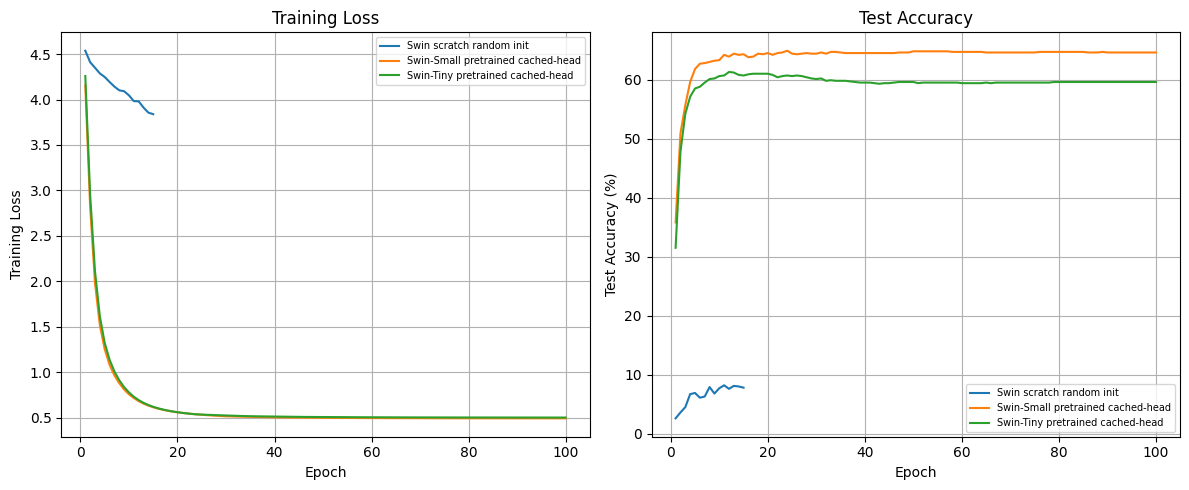

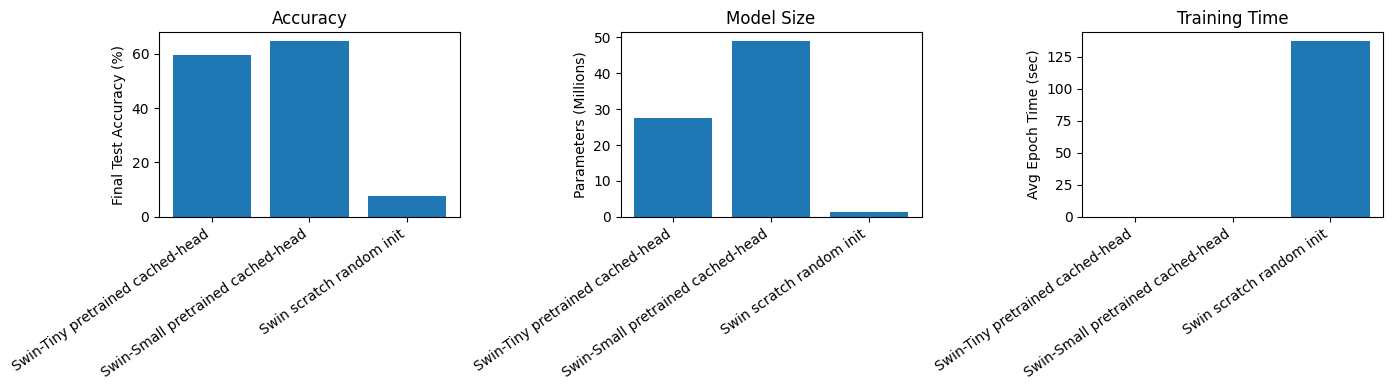

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for model_name in sorted(set(x['model'] for x in all_history)):
    rows = [x for x in all_history if x['model'] == model_name]
    plt.plot([x['epoch'] for x in rows], [x['train_loss'] for x in rows], label=model_name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss')
plt.legend(fontsize=7)
plt.grid(True)

plt.subplot(1, 2, 2)
for model_name in sorted(set(x['model'] for x in all_history)):
    rows = [x for x in all_history if x['model'] == model_name]
    plt.plot([x['epoch'] for x in rows], [x['test_acc'] for x in rows], label=model_name)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy')
plt.legend(fontsize=7)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'problem2_training_curves.png'), dpi=200)
plt.show()


names = [x['model'] for x in all_summary]
accs = [x['final_test_acc'] for x in all_summary]
params_m = [x['total_parameters'] / 1e6 for x in all_summary]
times = [x['avg_epoch_time_sec'] for x in all_summary]

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.bar(names, accs)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Final Test Accuracy (%)')
plt.title('Accuracy')

plt.subplot(1, 3, 2)
plt.bar(names, params_m)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Parameters (Millions)')
plt.title('Model Size')

plt.subplot(1, 3, 3)
plt.bar(names, times)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Avg Epoch Time (sec)')
plt.title('Training Time')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'problem2_summary_plots.png'), dpi=200)
plt.show()

## Notes for the Report

Use `problem2_summary.csv` for the main table. The required comparison is Swin-Tiny pretrained, Swin-Small pretrained, and scratch Swin. The important columns are final test accuracy, best test accuracy, average epoch time, total training time, feature extraction time, total parameters, trainable parameters, and FLOPs proxy.

For the report, mention that the original 5-epoch assignment setting with `2e-5` learned very slowly because the classifier head was randomly initialized. The improved run freezes the pretrained Swin backbone, extracts backbone features once, and trains the classification head longer with a larger head learning rate. This keeps the pretrained-vs-scratch comparison, but gives much better accuracy on CPU.